# Binary Classification with a Tabular Stroke Prediction Dataset - İnme Tahmini Veri Kümesiyle İkili Sınıflandırma

Felç (stroke), dünya genelinde ölüm ve kalıcı sakatlık nedenleri arasında önemli bir yere sahip olan ciddi bir sağlık problemidir. Erken teşhis ve risk faktörlerinin doğru değerlendirilmesi, hastalığın önlenmesi ve etkilerinin azaltılması açısından büyük önem taşımaktadır. Son yıllarda makine öğrenmesi yöntemleri, sağlık alanında büyük veri setlerinden anlamlı bilgiler elde ederek hastalık tahmini konusunda başarılı sonuçlar vermektedir. Bu projede, bireylere ait demografik ve sağlık verileri kullanılarak felç geçirme riskinin tahmin edilmesi amaçlanmıştır. Veri ön işleme, özellik mühendisliği ve çeşitli sınıflandırma algoritmalarının uygulanması sonucunda en başarılı model belirlenmiş ve performansı farklı değerlendirme metrikleri ile analiz edilmiştir.


### Sütun Açıklamaları

**id**: Her birey için oluşturulmuş benzersiz kimlik numarasıdır. Analiz açısından anlamlı bilgi taşımadığı için model eğitiminde genellikle kullanılmaz.

**gender**: Bireyin cinsiyet bilgisini ifade eder (Male, Female, Other).

**age**: Bireyin yaşını göstermektedir. Felç riskini etkileyen en önemli değişkenlerden biridir.

**hypertension**: Bireyin hipertansiyon (yüksek tansiyon) hastalığına sahip olup olmadığını belirtir. (0: Yok, 1: Var)

**heart_disease**: Bireyin kalp hastalığı geçmişine sahip olup olmadığını gösterir. (0: Yok, 1: Var)

**ever_married**: Bireyin daha önce evlenip evlenmediğini ifade eder. (Yes: Evet, No: Hayır)

**work_type**: Bireyin çalışma durumunu veya meslek grubunu belirtir (Private, Self-employed, Government Job, Children vb.).

**Residence_type**: Bireyin yaşadığı bölgenin türünü gösterir. (Urban: Kentsel, Rural: Kırsal)

**avg_glucose_level**: Bireyin ortalama kan şekeri (glikoz) seviyesini ifade eder. Yüksek glikoz seviyeleri sağlık riskleriyle ilişkilendirilebilir.

**bmi**: Vücut Kitle İndeksi (Body Mass Index) değeridir. Boy ve kilo bilgilerine göre hesaplanan bir sağlık göstergesidir.

**smoking_status**: Bireyin sigara kullanım durumunu belirtir (Never Smoked, Formerly Smoked, Smokes, Unknown).

**stroke**: Hedef değişkendir ve bireyin felç geçirip geçirmediğini gösterir. (0: Felç Geçirmedi, 1: Felç Geçirdi)

### Veri seti linki

https://www.kaggle.com/competitions/playground-series-s3e2/data

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
# Veri işleme
import pandas as pd
import numpy as np

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Ön işleme
from sklearn.preprocessing import LabelEncoder

# Veri bölme
from sklearn.model_selection import train_test_split

# Modeller
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB

# Performans metrikleri
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Uyarıları kapat
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/playground-series-s3e2/sample_submission.csv
/kaggle/input/competitions/playground-series-s3e2/train.csv
/kaggle/input/competitions/playground-series-s3e2/test.csv


In [3]:
df = pd.read_csv("/kaggle/input/competitions/playground-series-s3e2/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s3e2/test.csv")

In [4]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,Male,28.0,0,0,Yes,Private,Urban,79.53,31.1,never smoked,0
1,1,Male,33.0,0,0,Yes,Private,Rural,78.44,23.9,formerly smoked,0
2,2,Female,42.0,0,0,Yes,Private,Rural,103.00,40.3,Unknown,0
3,3,Male,56.0,0,0,Yes,Private,Urban,64.87,28.8,never smoked,0
4,4,Female,24.0,0,0,No,Private,Rural,73.36,28.8,never smoked,0


In [5]:
df.shape

(15304, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15304 entries, 0 to 15303
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 15304 non-null  int64  
 1   gender             15304 non-null  object 
 2   age                15304 non-null  float64
 3   hypertension       15304 non-null  int64  
 4   heart_disease      15304 non-null  int64  
 5   ever_married       15304 non-null  object 
 6   work_type          15304 non-null  object 
 7   Residence_type     15304 non-null  object 
 8   avg_glucose_level  15304 non-null  float64
 9   bmi                15304 non-null  float64
 10  smoking_status     15304 non-null  object 
 11  stroke             15304 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 1.4+ MB


In [7]:
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [8]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,15304.000000,15304.000000,15304.000000,15304.000000,15304.000000,15304.000000,15304.000000
mean,7651.500000,41.417708,0.049726,0.023327,89.039853,28.112721,0.041296
std,4418.028595,21.444673,0.217384,0.150946,25.476102,6.722315,0.198981
min,0.000000,0.080000,0.000000,0.000000,55.220000,10.300000,0.000000
25%,3825.750000,26.000000,0.000000,0.000000,74.900000,23.500000,0.000000
50%,7651.500000,43.000000,0.000000,0.000000,85.120000,27.600000,0.000000
75%,11477.250000,57.000000,0.000000,0.000000,96.980000,32.000000,0.000000
max,15303.000000,82.000000,1.000000,1.000000,267.600000,80.100000,1.000000


In [9]:
df["stroke"].value_counts()

stroke
0    14672
1      632
Name: count, dtype: int64

In [11]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [12]:
df.select_dtypes(include="object").columns

Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object')

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])
    test[col] = le.transform(test[col])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15304 entries, 0 to 15303
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 15304 non-null  int64  
 1   gender             15304 non-null  int64  
 2   age                15304 non-null  float64
 3   hypertension       15304 non-null  int64  
 4   heart_disease      15304 non-null  int64  
 5   ever_married       15304 non-null  int64  
 6   work_type          15304 non-null  int64  
 7   Residence_type     15304 non-null  int64  
 8   avg_glucose_level  15304 non-null  float64
 9   bmi                15304 non-null  float64
 10  smoking_status     15304 non-null  int64  
 11  stroke             15304 non-null  int64  
dtypes: float64(3), int64(9)
memory usage: 1.4 MB


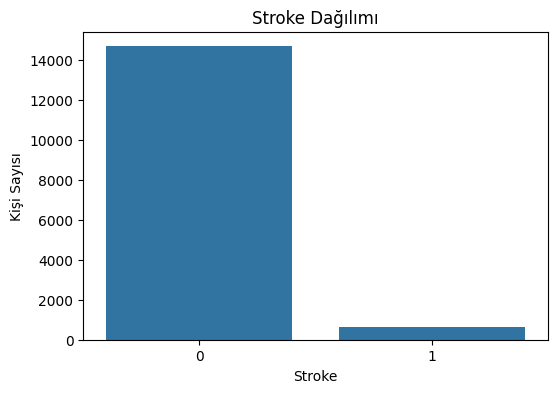

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x="stroke", data=df)

plt.title("Stroke Dağılımı")
plt.xlabel("Stroke")
plt.ylabel("Kişi Sayısı")

plt.show()

Grafik, veri setinde felç geçirmeyen bireylerin sayısının felç geçiren bireylere göre çok daha fazla olduğunu göstermektedir. Bu durum veri setinin dengesiz bir yapıya sahip olduğunu ortaya koymaktadır. Bu nedenle model performansının değerlendirilmesinde yalnızca Accuracy değeri yeterli olmayıp Precision, Recall ve F1-Score metriklerinin de dikkate alınması gerekmektedir.


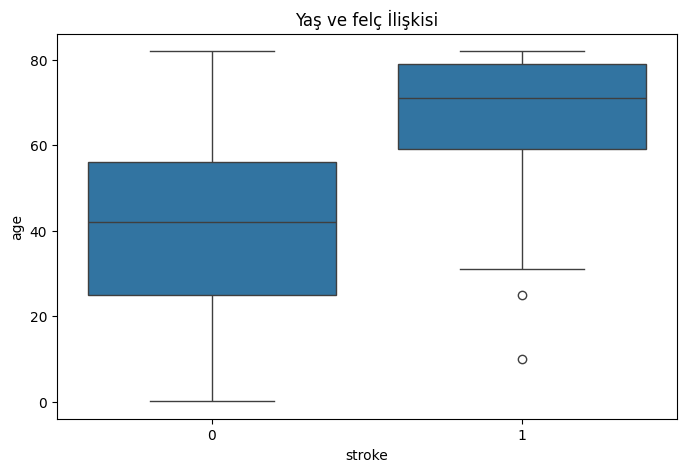

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(x="stroke", y="age", data=df)

plt.title("Yaş ve felç İlişkisi")
plt.show()

Grafik, felç geçiren bireylerin yaş ortalamasının ve yaş dağılımının felç geçirmeyen bireylere göre daha yüksek olduğunu göstermektedir. Bu sonuç, yaş arttıkça felç riskinin de arttığını ortaya koymaktadır.


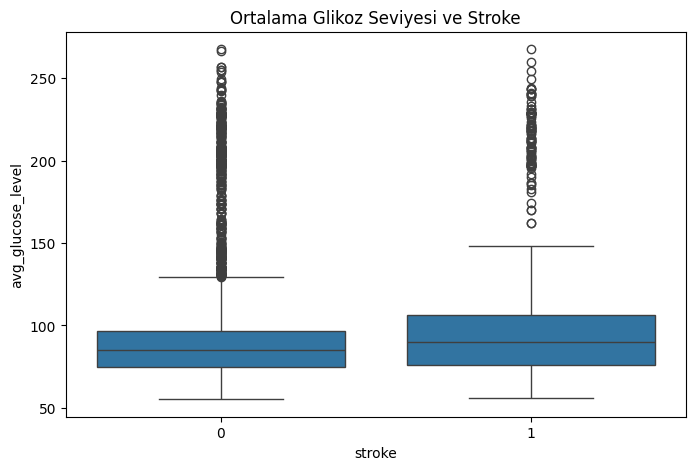

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(x="stroke", y="avg_glucose_level", data=df)

plt.title("Ortalama Glikoz Seviyesi ve Stroke")
plt.show()

Felç geçiren bireylerin ortalama glikoz seviyeleri genel olarak daha yüksektir. Bu sonuç, yüksek kan şekeri seviyesinin felç riskini artırabilecek önemli faktörlerden biri olduğunu göstermektedir.


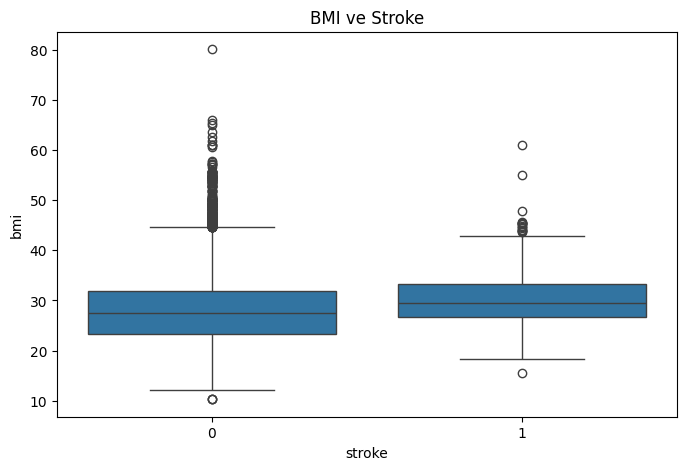

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(x="stroke", y="bmi", data=df)

plt.title("BMI ve Stroke")
plt.show()

Felç geçiren bireylerin BMI ( Vücut Kitle İndeksi) değerleri genel olarak biraz daha yüksek olsa da iki grup arasında belirgin bir fark bulunmamaktadır. BMI tek başına felç riskini açıklamak için yeterli görünmemektedir.


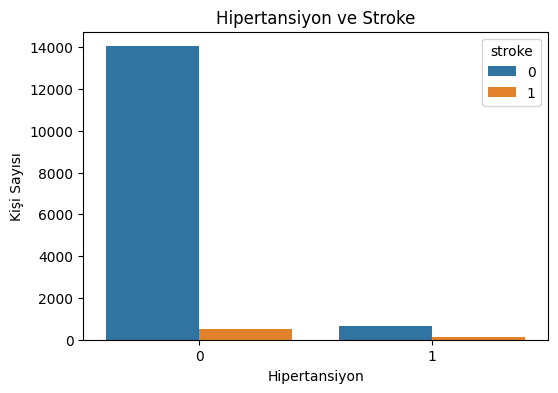

In [34]:
plt.figure(figsize=(6,4))
sns.countplot(x="hypertension", hue="stroke", data=df)

plt.title("Hipertansiyon ve Stroke")
plt.xlabel("Hipertansiyon")
plt.ylabel("Kişi Sayısı")

plt.show()

Hipertansiyona sahip bireylerde felç görülme oranı daha yüksektir. Sonuçlar, hipertansiyonun felç riskini artıran önemli değişkenlerden biri olduğunu göstermektedir.


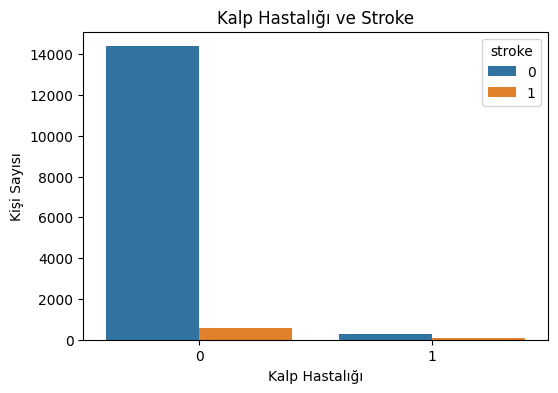

In [35]:
plt.figure(figsize=(6,4))
sns.countplot(x="heart_disease", hue="stroke", data=df)

plt.title("Kalp Hastalığı ve Stroke")
plt.xlabel("Kalp Hastalığı")
plt.ylabel("Kişi Sayısı")

plt.show()

Kalp hastalığı bulunan bireylerde felç görülme oranı daha yüksektir. Bu sonuç, kalp hastalığının felç riskini artıran önemli sağlık faktörlerinden biri olduğunu göstermektedir.


In [16]:
x = df.drop(["id", "stroke"], axis=1)

y = df["stroke"]

In [17]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [18]:
print(x.shape)
print(y.shape)

print(x_train.shape)
print(x_test.shape)

(15304, 10)
(15304,)
(12243, 10)
(3061, 10)


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

model_lr = lr.fit(x_train, y_train)

tahmin_lr = model_lr.predict(x_test)

accuracy_score(y_test, tahmin_lr)

0.9588369813786344

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)

model_dt = dt.fit(x_train, y_train)

tahmin_dt = model_dt.predict(x_test)

accuracy_score(y_test, tahmin_dt)

0.9225743221169552

In [21]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

gb = GradientBoostingClassifier(random_state=42)

model_gb = gb.fit(x_train, y_train)

tahmin_gb = model_gb.predict(x_test)

accuracy_score(y_test, tahmin_gb)

0.957530218882718

In [22]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score

et = ExtraTreesClassifier(random_state=42)

model_et = et.fit(x_train, y_train)

tahmin_et = model_et.predict(x_test)

accuracy_score(y_test, tahmin_et)

0.9555700751388435

In [23]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

nb = GaussianNB()

model_nb = nb.fit(x_train, y_train)

tahmin_nb = model_nb.predict(x_test)

accuracy_score(y_test, tahmin_nb)

0.903952956550147

In [24]:
sonuc = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Gradient Boosting",
        "Extra Trees",
        "Naive Bayes"
    ],
    "Accuracy":[
        accuracy_score(y_test, tahmin_lr),
        accuracy_score(y_test, tahmin_dt),
        accuracy_score(y_test, tahmin_gb),
        accuracy_score(y_test, tahmin_et),
        accuracy_score(y_test, tahmin_nb)
    ]
})

sonuc.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,Logistic Regression,0.958837
2,Gradient Boosting,0.957530
3,Extra Trees,0.955570
1,Decision Tree,0.922574
4,Naive Bayes,0.903953


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import pandas as pd


def algo_test_classification(x, y):
    
    LR = LogisticRegression(max_iter=1000)
    NB = GaussianNB()
    GB = GradientBoostingClassifier(random_state=42)
    ET = ExtraTreesClassifier(random_state=42)
    DT = DecisionTreeClassifier(random_state=42)
    
    algos = [LR, NB, GB, ET, DT]
    
    algo_names = [
        "Logistic Regression",
        "Naive Bayes",
        "Gradient Boosting",
        "Extra Trees",
        "Decision Tree"
    ]
    
    x_train, x_test, y_train, y_test = train_test_split(
        x,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )
    
    accuracy = []
    precision = []
    recall = []
    f1 = []
    
    for algo in algos:
        p = algo.fit(x_train, y_train).predict(x_test)
        
        accuracy.append(accuracy_score(y_test, p))
        precision.append(precision_score(y_test, p, zero_division=0))
        recall.append(recall_score(y_test, p, zero_division=0))
        f1.append(f1_score(y_test, p, zero_division=0))
    
    result = pd.DataFrame({
        "Model": algo_names,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1
    })
    
    return result.sort_values("F1_Score", ascending=False)

In [26]:
algo_test_classification(x, y)

,Model,Accuracy,Precision,Recall,F1_Score
1,Naive Bayes,0.903953,0.188889,0.404762,0.257576
4,Decision Tree,0.922574,0.163636,0.214286,0.185567
2,Gradient Boosting,0.957530,0.400000,0.063492,0.109589
3,Extra Trees,0.955570,0.307692,0.063492,0.105263
0,Logistic Regression,0.958837,0.500000,0.023810,0.045455


## Sonuç

Çalışmada farklı sınıflandırma algoritmaları karşılaştırılmış ve en başarılı sonuç Naive Bayes modeli ile elde edilmiştir. Naive Bayes modeli, felç vakalarını tespit etmede diğer modellere göre daha yüksek Recall ve F1-Score değerleri göstermiştir. Sonuçlar, veri setinin dengesiz yapısı nedeniyle Accuracy değerlerinin tek başına yeterli olmadığını ve model değerlendirmesinde Recall ile F1-Score metriklerinin daha önemli olduğunu ortaya koymuştur.
